## 1. Importação de Bibliotecas Essenciais

In [10]:
# Importa bibliotecas necessárias
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import warnings
warnings.filterwarnings('ignore')

# Define caminho absoluto para src
notebook_path = Path.cwd()
project_root = notebook_path.parent
src_path = project_root / 'src'

# Adiciona ao path
sys.path.insert(0, str(src_path))

print(f"Caminho do src: {src_path}")
print(f"Existe: {src_path.exists()}")

try:
    from fits_reader import FITSReader, load_fits
    from image_processor import ImageProcessor
    from rgb_converter import RGBConverter
    from pipeline import AstroDataVizPipeline
    from synthetic_fits_generator import create_test_fits_collection, create_synthetic_image
    print("✅ Bibliotecas importadas com sucesso!")
except ImportError as e:
    print(f"❌ Erro ao importar: {e}")
    print("Certifique-se de que as dependências estão instaladas:")
    print("pip install -r ../requirements.txt")

Caminho do src: c:\Users\erikc\OneDrive\Documentos\astro-data-viz-python\astro-data-viz-python\src
Existe: True
✅ Bibliotecas importadas com sucesso!


## 2. Geração de Dados FITS Sintéticos

Criando dados de teste realistas que simulam observações de telescópios espaciais.

In [11]:
# Cria arquivos FITS sintéticos para demonstração
fits_files = create_test_fits_collection("../data/raw")
print(f"\n✅ {len(fits_files)} arquivos FITS sintéticos criados:")
for f in fits_files[:3]:
    print(f"  - {Path(f).name}")
print(f"  ... e mais {len(fits_files) - 3}")

INFO:synthetic_fits_generator:Arquivo FITS sintético criado: ..\data\raw\synthetic_multiband.fits
INFO:synthetic_fits_generator:Arquivo FITS monocromático criado: ..\data\raw\synthetic_monochrome.fits
INFO:synthetic_fits_generator:Arquivo FITS monocromático criado: ..\data\raw\synthetic_monochrome.fits
INFO:synthetic_fits_generator:Arquivo FITS monocromático criado: ..\data\raw\synthetic_band_ultraviolet.fits
INFO:synthetic_fits_generator:Arquivo FITS monocromático criado: ..\data\raw\synthetic_band_ultraviolet.fits
INFO:synthetic_fits_generator:Arquivo FITS monocromático criado: ..\data\raw\synthetic_band_blue.fits
INFO:synthetic_fits_generator:Arquivo FITS monocromático criado: ..\data\raw\synthetic_band_blue.fits
INFO:synthetic_fits_generator:Arquivo FITS monocromático criado: ..\data\raw\synthetic_band_green.fits
INFO:synthetic_fits_generator:Arquivo FITS monocromático criado: ..\data\raw\synthetic_band_green.fits
INFO:synthetic_fits_generator:Arquivo FITS monocromático criado: ..\


✅ 7 arquivos FITS sintéticos criados:
  - synthetic_multiband.fits
  - synthetic_monochrome.fits
  - synthetic_band_ultraviolet.fits
  ... e mais 4


## 3. Inspeção de Arquivos FITS

Explorando a estrutura e metadados dos arquivos FITS.

In [12]:
# Inspeciona um arquivo FITS
fits_path = "../data/raw/synthetic_multiband.fits"

with FITSReader(fits_path) as reader:
    print(reader.get_info())
    data = reader.get_primary_data()
    if data is not None:
        print(f"\nDados primários:")
        print(f"  Shape: {data.shape}")
        print(f"  Tipo: {data.dtype}")
        print(f"  Min: {np.nanmin(data):.2e}")
        print(f"  Max: {np.nanmax(data):.2e}")
        print(f"  Mean: {np.nanmean(data):.2e}")

INFO:fits_reader:Arquivo FITS carregado: ..\data\raw\synthetic_multiband.fits


Arquivo: synthetic_multiband.fits
Número de HDUs: 4

HDU 0: PRIMARY

HDU 1: BAND_0
  Shape: (512, 512)
  Data type: >f4
  Min: 1.99e+01, Max: 1.11e+03

HDU 2: BAND_1
  Shape: (512, 512)
  Data type: >f4
  Min: 2.65e+01, Max: 1.44e+03

HDU 3: BAND_2
  Shape: (512, 512)
  Data type: >f4
  Min: 5.35e+01, Max: 1.92e+03


## 4. Normalização e Pré-processamento

Aplicando técnicas de normalização aos dados brutos.

INFO:fits_reader:Arquivo FITS carregado: ..\data\raw\synthetic_monochrome.fits


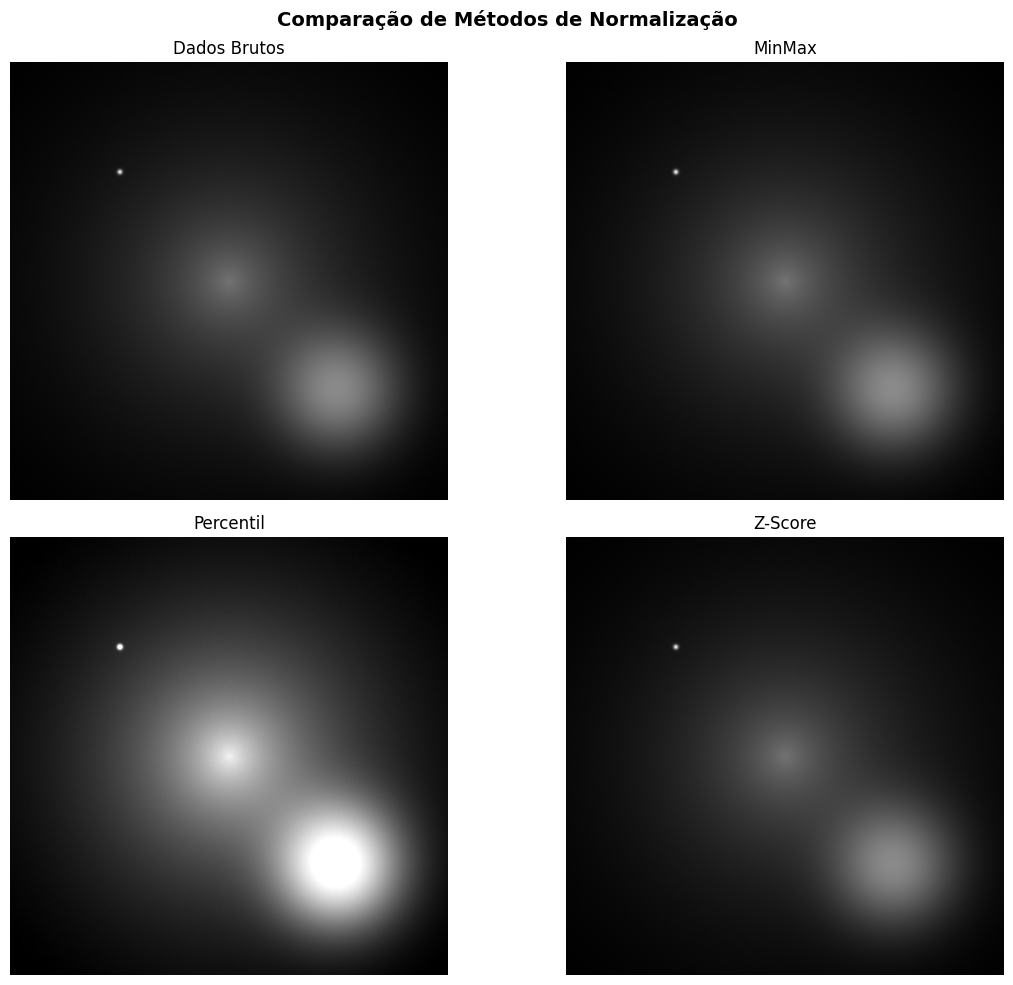

✅ Normalização comparada


In [13]:
# Carrega dados brutos
raw_data = load_fits("../data/raw/synthetic_monochrome.fits")

# Demonstra diferentes métodos de normalização
norm_minmax = ImageProcessor.normalize(raw_data, method="minmax")
norm_percentile = ImageProcessor.normalize(raw_data, method="percentile")
norm_zscore = ImageProcessor.normalize(raw_data, method="zscore")

# Visualiza comparação
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Comparação de Métodos de Normalização', fontsize=14, fontweight='bold')

axes[0,0].imshow(raw_data, cmap='gray')
axes[0,0].set_title('Dados Brutos')
axes[0,0].axis('off')

axes[0,1].imshow(norm_minmax, cmap='gray')
axes[0,1].set_title('MinMax')
axes[0,1].axis('off')

axes[1,0].imshow(norm_percentile, cmap='gray')
axes[1,0].set_title('Percentil')
axes[1,0].axis('off')

axes[1,1].imshow(norm_zscore, cmap='gray')
axes[1,1].set_title('Z-Score')
axes[1,1].axis('off')

plt.tight_layout()
plt.show()

print("✅ Normalização comparada")

## 5. Mapeamento de Comprimento de Onda para RGB

Convertendo observações em diferentes bandas espectrais para cores visíveis.

In [14]:
# Carrega dados multi-banda
with FITSReader("../data/raw/synthetic_multiband.fits") as reader:
    all_data = reader.get_all_data()

print(f"Bandas disponíveis: {len(all_data)}")

# Extrai e processa os primeiros 3 canais
channels = []
for i, (name, data) in enumerate(list(all_data.items())[:3]):
    processed = ImageProcessor.apply_pipeline(
        data,
        normalize_method="percentile",
        stretch_method="asinh",
        enhance=False
    )
    channels.append(processed)
    print(f"\n✅ Banda {i+1} processada: {name}")

# Combina em RGB
if len(channels) == 3:
    rgb_natural = RGBConverter.combine_channels(channels[0], channels[1], channels[2])
    rgb_hubble = RGBConverter.combine_channels(channels[2], channels[1], channels[0])
    print(f"\n✅ Imagens RGB criadas")

INFO:fits_reader:Arquivo FITS carregado: ..\data\raw\synthetic_multiband.fits
INFO:image_processor:Iniciando pipeline de processamento...
INFO:image_processor:Iniciando pipeline de processamento...
INFO:image_processor:NaN tratado
INFO:image_processor:Normalizado (percentile)
INFO:image_processor:NaN tratado
INFO:image_processor:Normalizado (percentile)
INFO:image_processor:Stretching aplicado (asinh)
INFO:image_processor:Pipeline concluído!
INFO:image_processor:Iniciando pipeline de processamento...
INFO:image_processor:NaN tratado
INFO:image_processor:Normalizado (percentile)
INFO:image_processor:Stretching aplicado (asinh)
INFO:image_processor:Pipeline concluído!
INFO:image_processor:Iniciando pipeline de processamento...
INFO:image_processor:NaN tratado
INFO:image_processor:Normalizado (percentile)
INFO:image_processor:Stretching aplicado (asinh)
INFO:image_processor:Pipeline concluído!
INFO:image_processor:Iniciando pipeline de processamento...
INFO:image_processor:NaN tratado
INF

Bandas disponíveis: 3

✅ Banda 1 processada: hdu_1_BAND_0

✅ Banda 2 processada: hdu_2_BAND_1

✅ Banda 3 processada: hdu_3_BAND_2

✅ Imagens RGB criadas


## 6. Criação de Imagens de Falsa Cor

Atribuindo bandas arbitrárias a canais RGB para revelar diferentes características.

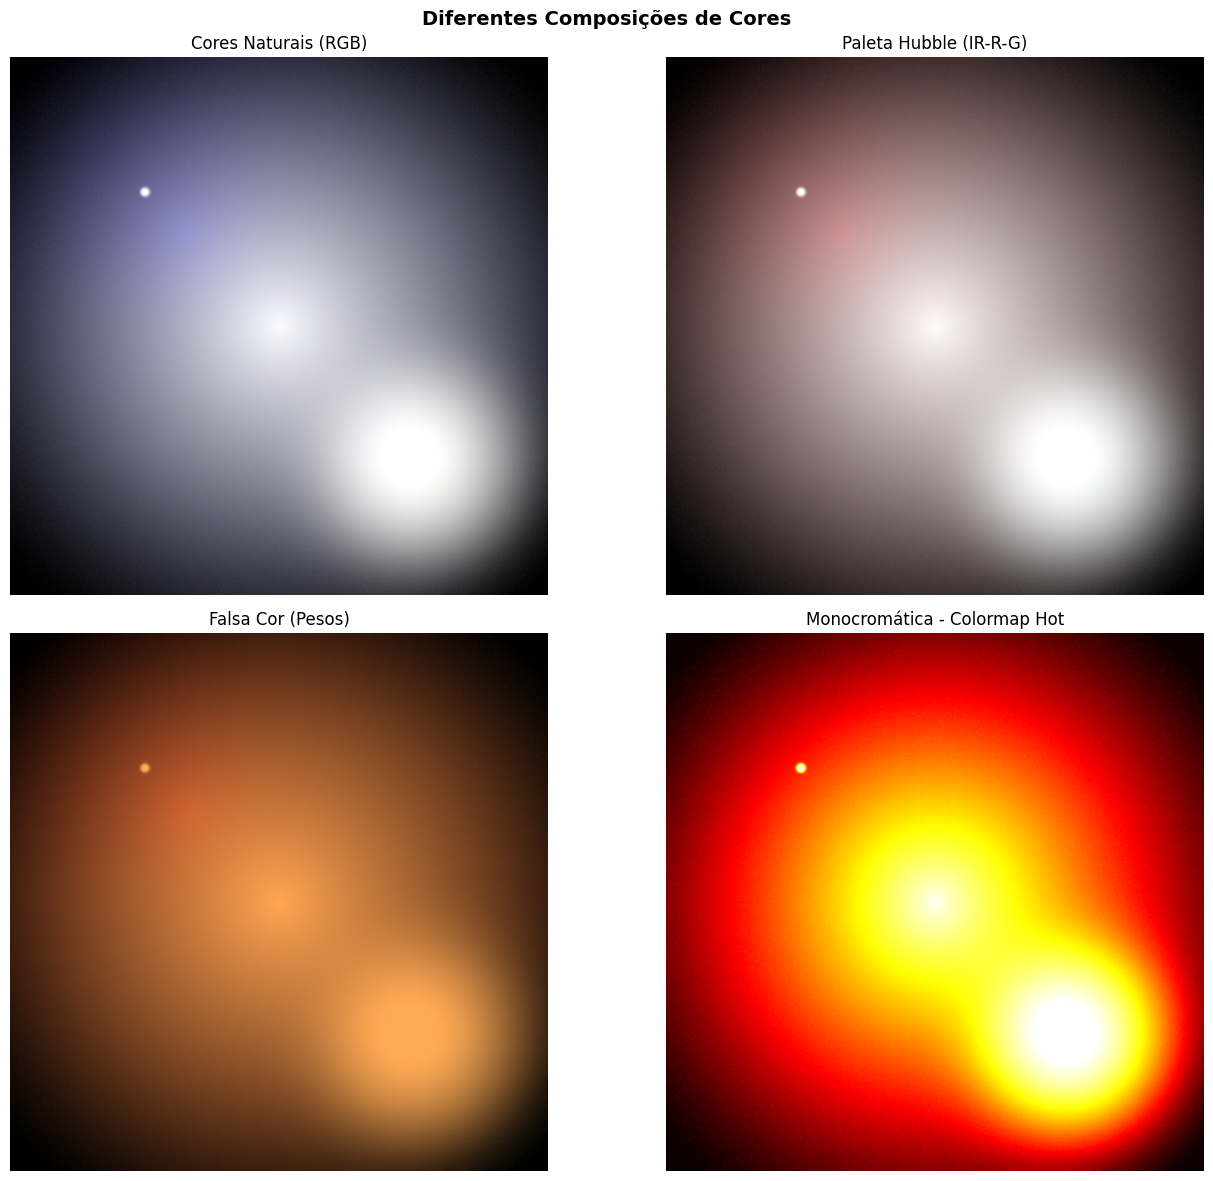

✅ Composições de falsa cor criadas


In [15]:
# Diferentes composições
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
fig.suptitle('Diferentes Composições de Cores', fontsize=14, fontweight='bold')

# Natural
axes[0,0].imshow(rgb_natural)
axes[0,0].set_title('Cores Naturais (RGB)')
axes[0,0].axis('off')

# Hubble
axes[0,1].imshow(rgb_hubble)
axes[0,1].set_title('Paleta Hubble (IR-R-G)')
axes[0,1].axis('off')

# Falsa cor com pesos
rgb_false = RGBConverter.combine_channels(
    channels[2], channels[1], channels[0],
    weights=(1.5, 1.0, 0.5)
)
axes[1,0].imshow(rgb_false)
axes[1,0].set_title('Falsa Cor (Pesos)')
axes[1,0].axis('off')

# Monocromática com colormap
rgb_hot = RGBConverter.colorize_monochrome(channels[0], "hot")
axes[1,1].imshow(rgb_hot)
axes[1,1].set_title('Monocromática - Colormap Hot')
axes[1,1].axis('off')

plt.tight_layout()
plt.show()

print("✅ Composições de falsa cor criadas")

## 7. Realce de Contraste e Qualidade

Aplicando técnicas avançadas de processamento para melhorar detales.

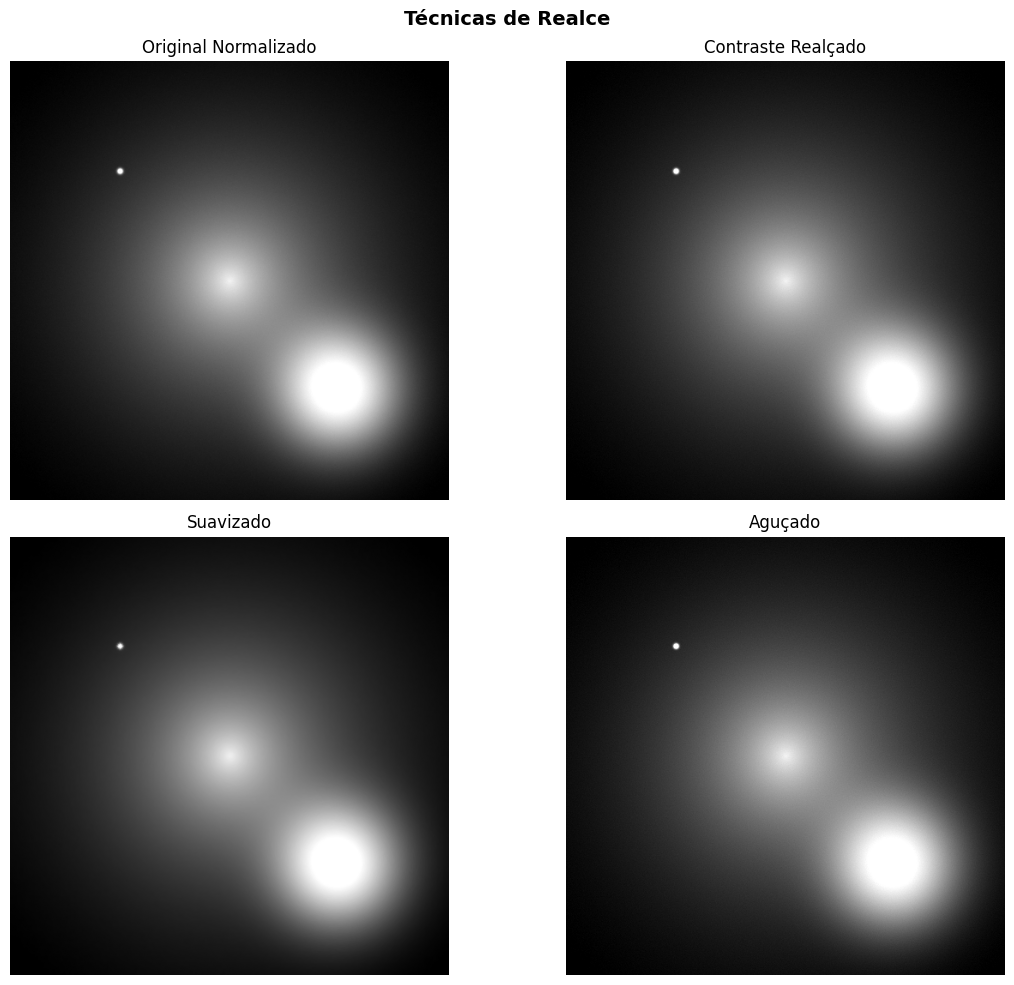

✅ Técnicas de realce comparadas


In [16]:
# Compara técnicas de realce
raw_normalized = ImageProcessor.normalize(raw_data, method="percentile")

enhanced = ImageProcessor.enhance_contrast(raw_normalized)
smoothed = ImageProcessor.smooth(raw_normalized, kernel_size=5)
sharpened = ImageProcessor.sharpen(raw_normalized, amount=0.8)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Técnicas de Realce', fontsize=14, fontweight='bold')

axes[0,0].imshow(raw_normalized, cmap='gray')
axes[0,0].set_title('Original Normalizado')
axes[0,0].axis('off')

axes[0,1].imshow(enhanced, cmap='gray')
axes[0,1].set_title('Contraste Realçado')
axes[0,1].axis('off')

axes[1,0].imshow(smoothed, cmap='gray')
axes[1,0].set_title('Suavizado')
axes[1,0].axis('off')

axes[1,1].imshow(sharpened, cmap='gray')
axes[1,1].set_title('Aguçado')
axes[1,1].axis('off')

plt.tight_layout()
plt.show()

print("✅ Técnicas de realce comparadas")

## 8. Combinação de Múltiplas Bandas em RGB

Processamento de dados multi-banda do começo ao fim.

In [19]:
# Pipeline completo - Versão Simplificada
print("Aplicando pipeline completo de processamento...\n")

try:
    # Carrega arquivo multi-banda manualmente
    print("📁 Carregando arquivo FITS...")
    fits_path = "../data/raw/synthetic_multiband.fits"
    
    with FITSReader(fits_path) as reader:
        all_data = reader.get_all_data()
    
    print(f"✅ Arquivo carregado com {len(all_data)} bandas")
    
    # Extrai os primeiros 3 canais e processa
    print("\n🔄 Processando canais...")
    processed_channels = []
    
    for i, (name, data) in enumerate(list(all_data.items())[:3]):
        processed = ImageProcessor.apply_pipeline(
            data,
            normalize_method="percentile",
            stretch_method="asinh",
            enhance=True,
            smooth_kernel=3
        )
        processed_channels.append(processed)
        print(f"  ✅ Canal {i+1} processado")
    
    # Combina em RGB
    print("\n🎨 Combinando em RGB...")
    rgb_resultado = RGBConverter.combine_channels(
        processed_channels[0], 
        processed_channels[1], 
        processed_channels[2]
    )
    
    print(f"✅ Imagem RGB criada")
    print(f"   Shape: {rgb_resultado.shape}")
    print(f"   Range: [{rgb_resultado.min():.3f}, {rgb_resultado.max():.3f}]")
    
    # Tenta salvar (opcional)
    try:
        import os
        os.makedirs("../data/processed", exist_ok=True)
        pipeline = AstroDataVizPipeline("../data/processed")
        pipeline._save_rgb_image(rgb_resultado, "../data/processed/notebook_demo.png")
        print(f"\n💾 Imagem salva em: ../data/processed/notebook_demo.png")
    except Exception as save_err:
        print(f"\n⚠️ Aviso ao salvar: {save_err}")
        print("   (Mas a imagem RGB foi criada com sucesso!)")
    
except Exception as e:
    print(f"\n❌ Erro: {e}")
    import traceback
    traceback.print_exc()
    rgb_resultado = None

INFO:fits_reader:Arquivo FITS carregado: ..\data\raw\synthetic_multiband.fits
INFO:image_processor:Iniciando pipeline de processamento...
INFO:image_processor:Iniciando pipeline de processamento...
INFO:image_processor:NaN tratado
INFO:image_processor:Normalizado (percentile)
INFO:image_processor:NaN tratado
INFO:image_processor:Normalizado (percentile)
INFO:image_processor:Stretching aplicado (asinh)
INFO:image_processor:Contraste realçado
INFO:image_processor:Stretching aplicado (asinh)
INFO:image_processor:Contraste realçado
INFO:image_processor:Suavização aplicada (kernel=3)
INFO:image_processor:Pipeline concluído!
INFO:image_processor:Iniciando pipeline de processamento...
INFO:image_processor:NaN tratado
INFO:image_processor:Normalizado (percentile)
INFO:image_processor:Suavização aplicada (kernel=3)
INFO:image_processor:Pipeline concluído!
INFO:image_processor:Iniciando pipeline de processamento...
INFO:image_processor:NaN tratado
INFO:image_processor:Normalizado (percentile)
IN

Aplicando pipeline completo de processamento...

📁 Carregando arquivo FITS...
✅ Arquivo carregado com 3 bandas

🔄 Processando canais...
  ✅ Canal 1 processado
  ✅ Canal 2 processado


INFO:image_processor:Suavização aplicada (kernel=3)
INFO:image_processor:Pipeline concluído!
INFO:image_processor:Pipeline concluído!
INFO:pipeline:Imagem salva em: ../data/processed/notebook_demo.png
INFO:pipeline:Imagem salva em: ../data/processed/notebook_demo.png


  ✅ Canal 3 processado

🎨 Combinando em RGB...
✅ Imagem RGB criada
   Shape: (512, 512, 3)
   Range: [0.000, 1.000]

💾 Imagem salva em: ../data/processed/notebook_demo.png


## 9. Visualização de Resultados Finais

Exibição das imagens RGB processadas.

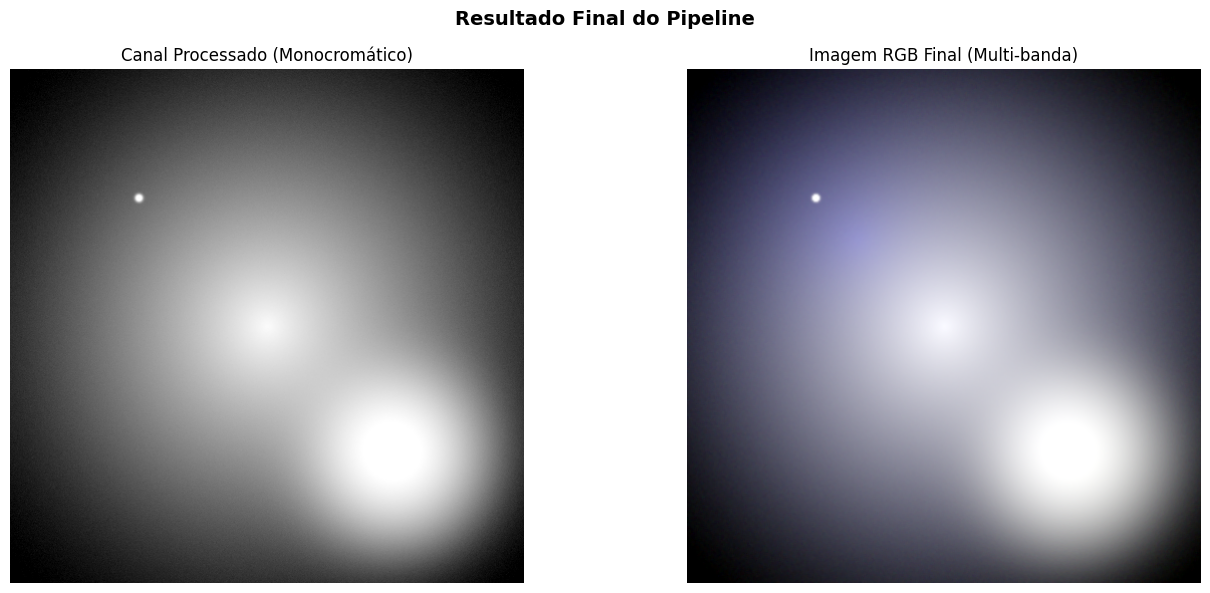


✅ Pipeline de visualização completo!


In [20]:
# Visualiza resultado
if 'rgb_resultado' in locals() and rgb_resultado is not None:
    fig = plt.figure(figsize=(14, 6))
    gs = GridSpec(1, 2, figure=fig)

    ax1 = fig.add_subplot(gs[0, 0])
    ax1.imshow(channels[0], cmap='gray')
    ax1.set_title('Canal Processado (Monocromático)', fontsize=12)
    ax1.axis('off')

    ax2 = fig.add_subplot(gs[0, 1])
    ax2.imshow(rgb_resultado)
    ax2.set_title('Imagem RGB Final (Multi-banda)', fontsize=12)
    ax2.axis('off')

    plt.suptitle('Resultado Final do Pipeline', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

    print("\n✅ Pipeline de visualização completo!")
else:
    print("⚠️ rgb_resultado não está disponível. Execute a célula anterior primeiro.")

## 10. Comparação de Diferentes Técnicas de Stretching

Demonstrando o impacto de diferentes métodos de stretching.

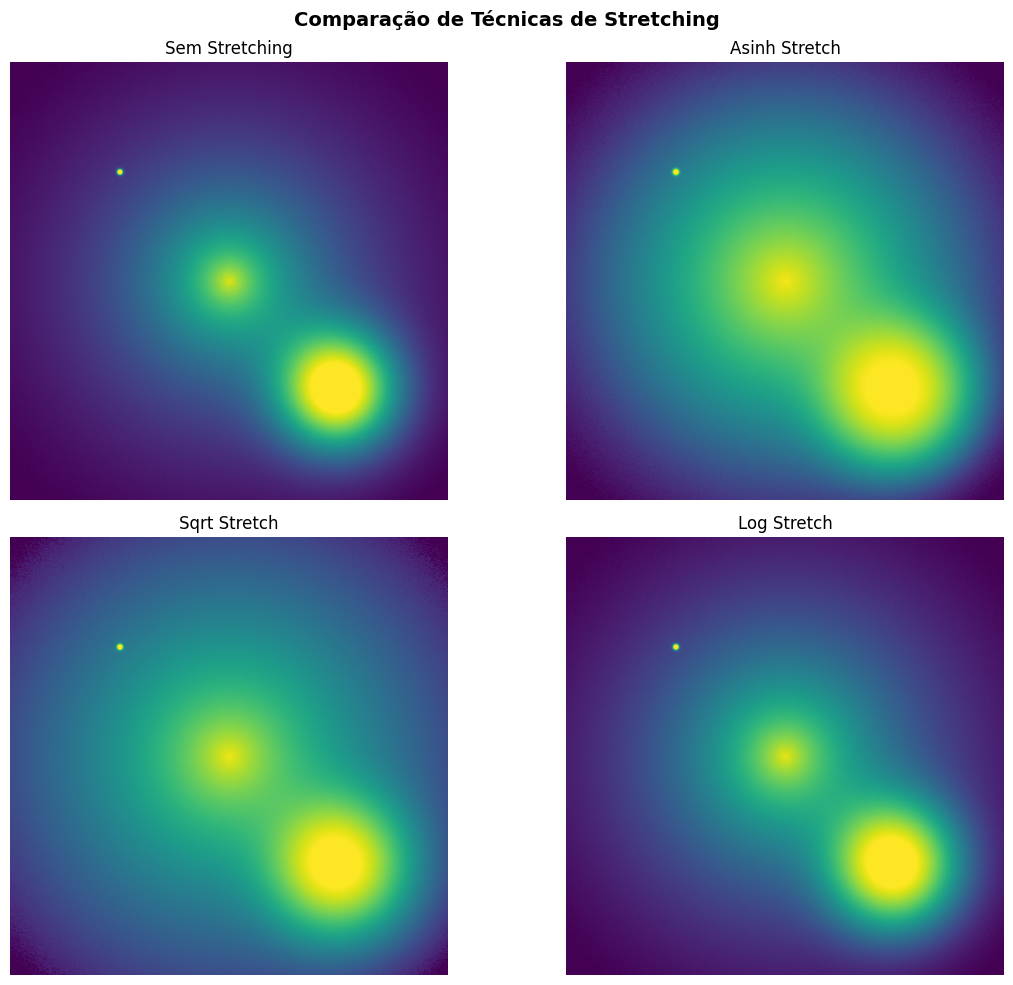

✅ Técnicas de stretching comparadas


In [21]:
# Compara diferentes stretches
normalized = ImageProcessor.normalize(raw_data, method="percentile")

asinh = ImageProcessor.asinh_stretch(normalized)
sqrt = ImageProcessor.sqrt_stretch(normalized)
log = ImageProcessor.log_stretch(normalized)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Comparação de Técnicas de Stretching', fontsize=14, fontweight='bold')

axes[0,0].imshow(normalized, cmap='viridis')
axes[0,0].set_title('Sem Stretching')
axes[0,0].axis('off')

axes[0,1].imshow(asinh, cmap='viridis')
axes[0,1].set_title('Asinh Stretch')
axes[0,1].axis('off')

axes[1,0].imshow(sqrt, cmap='viridis')
axes[1,0].set_title('Sqrt Stretch')
axes[1,0].axis('off')

axes[1,1].imshow(log, cmap='viridis')
axes[1,1].set_title('Log Stretch')
axes[1,1].axis('off')

plt.tight_layout()
plt.show()

print("✅ Técnicas de stretching comparadas")

## 11. Diferentes Colormaps

Explorando diversas paletas de cores disponíveis.

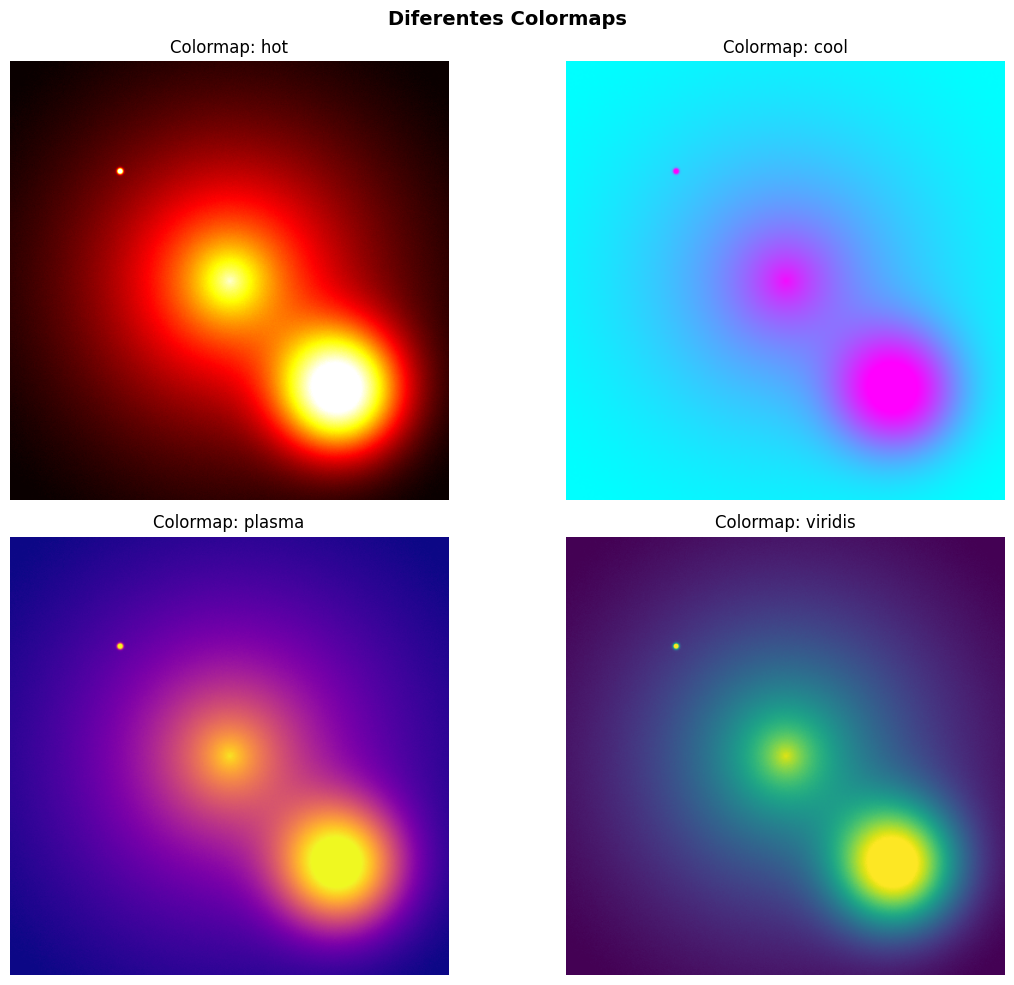

✅ Colormaps comparados


In [22]:
# Testa diferentes colormaps
colormaps = ["hot", "cool", "plasma", "viridis"]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Diferentes Colormaps', fontsize=14, fontweight='bold')

for idx, (ax, cmap_name) in enumerate(zip(axes.flat, colormaps)):
    rgb = RGBConverter.colorize_monochrome(normalized, cmap_name)
    ax.imshow(rgb)
    ax.set_title(f'Colormap: {cmap_name}')
    ax.axis('off')

plt.tight_layout()
plt.show()

print("✅ Colormaps comparados")

## 12. Salvamento de Imagens Processadas

Exportando resultados finais em formato PNG.

In [23]:
# Salva diferentes versões processadas
pipeline = AstroDataVizPipeline("../data/processed")

processed_combined = ImageProcessor.apply_pipeline(
    raw_data,
    normalize_method="percentile",
    stretch_method="asinh",
    enhance=True,
    smooth_kernel=3
)

rgb_final = RGBConverter.colorize_monochrome(processed_combined, "hot")

pipeline._save_rgb_image(rgb_final, "../data/processed/notebook_final_result.png")

print("✅ Imagem final salva em: ../data/processed/notebook_final_result.png")
print(f"\n📊 Resumo do processamento:")
print(f"  • Dados originais: {raw_data.shape}")
print(f"  • Dados processados: {rgb_final.shape}")
print(f"  • Tipo: RGB (3 canais)")
print(f"  • Range: [0.0, 1.0]")
print(f"\n✨ Pipeline concluído com sucesso!")

INFO:image_processor:Iniciando pipeline de processamento...
INFO:image_processor:NaN tratado
INFO:image_processor:Normalizado (percentile)
INFO:image_processor:NaN tratado
INFO:image_processor:Normalizado (percentile)
INFO:image_processor:Stretching aplicado (asinh)
INFO:image_processor:Stretching aplicado (asinh)
INFO:image_processor:Contraste realçado
INFO:image_processor:Contraste realçado
INFO:image_processor:Suavização aplicada (kernel=3)
INFO:image_processor:Pipeline concluído!
INFO:image_processor:Suavização aplicada (kernel=3)
INFO:image_processor:Pipeline concluído!
INFO:pipeline:Imagem salva em: ../data/processed/notebook_final_result.png
INFO:pipeline:Imagem salva em: ../data/processed/notebook_final_result.png


✅ Imagem final salva em: ../data/processed/notebook_final_result.png

📊 Resumo do processamento:
  • Dados originais: (512, 512)
  • Dados processados: (512, 512, 3)
  • Tipo: RGB (3 canais)
  • Range: [0.0, 1.0]

✨ Pipeline concluído com sucesso!


---

## 📚 Resumo do Pipeline

Este notebook demonstrou:

1. ✅ **Carregamento FITS**: Leitura de arquivos astronômicos
2. ✅ **Normalização**: Diferentes métodos de escala
3. ✅ **Stretching**: Técnicas para realçar contraste
4. ✅ **Colorização**: Mapeamento de bandas para RGB
5. ✅ **Realce**: Técnicas de processamento avançado
6. ✅ **Colormaps**: Paletas de cores variadas
7. ✅ **Salvamento**: Exportação em PNG

## 🔗 Próximos Passos

- Explore os exemplos em `../examples/`
- Consulte a documentação em `../README_PROJETO.md`
- Execute os testes: `pytest ../tests/`

## 🌌 Sobre

**Astro Data Visualization v1.0.0**  
Projeto de visualização de dados astronômicos  
Autor: Erik Costa Souza